<a href="https://colab.research.google.com/github/viktor-tkachenko/data-analytics-portfolio/blob/main/python/Exploratory_data_analysis_for_online_store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data overview

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from matplotlib.ticker import FuncFormatter
currency_formatter = FuncFormatter(
    lambda x, p: f'${x/1_000_000:.0f}M')
thousands_formatter = FuncFormatter(
    lambda x, p: f'{x/1000:.0f}K')

from google.colab import drive


drive.mount("/content/drive")
%cd /content/drive/MyDrive/mate_edu
events = pd.read_csv("events.csv")
products = pd.read_csv("products.csv")
countries = pd.read_csv("countries.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/mate_edu


In [2]:
print(f'Events table:\n {events.head()}')
print(f'Products table:\n {products.head()}')
print(f'Countries table:\n {countries.head()}')

Events table:
     Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.79  
Products table:
      id        item_type
0  2103           Cereal
1  7940        Household
2  2455          Clothes
3  1270        Beverages
4  8681  Office Supplies
Countries table:
        

> The dataset consists of three main tables: Events, Products, and Countries. The Events table contains transactional information, including order identifiers, order and shipping dates, order priority, destination country, product identifiers, sales channel, units sold, unit price, and unit cost. The Products table provides product metadata by linking each product ID to its corresponding product category. The Countries table contains geographic information about each country, including ISO country codes, region, and sub-region classifications. Together, these tables allow for the analysis of sales performance, profitability, logistics efficiency, geographic distribution, and temporal trends across products, countries, and regions.

# 2. Data cleaning

## 2.1. Events table cleaning

In [3]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB




> Checking missing values



In [4]:
print(events.isna().sum())
print(events.isna().sum() / events.shape[0] * 100)

Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64
Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [5]:
events = events.dropna(subset=['Units Sold'])



> At this stage, it is preferable to retain the NaN values in the country code column, as removing these records could result in the loss of potentially valuable information contained in other fields.



In [6]:
print(events.isna().sum())

Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         0
Unit Price         0
Unit Cost          0
dtype: int64




> Standardizing column names and convert data types



In [7]:
events.columns = (
    events.columns
    .str.lower()
    .str.replace(' ', '_'))

events = events.astype({
    'order_date': 'datetime64[ns]',
    'ship_date': 'datetime64[ns]'})

In [8]:
events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1328 non-null   int64         
 1   order_date      1328 non-null   datetime64[ns]
 2   ship_date       1328 non-null   datetime64[ns]
 3   order_priority  1328 non-null   object        
 4   country_code    1246 non-null   object        
 5   product_id      1328 non-null   int64         
 6   sales_channel   1328 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1328 non-null   float64       
 9   unit_cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 114.1+ KB




> Removing leading and trailing spaces from all string columns. Standardizing string values



In [9]:
for col in events.select_dtypes(include='object').columns:
    events[col] = events[col].str.strip()

events['sales_channel'] = events['sales_channel'].str.title()
events['order_priority'] = events['order_priority'].str.upper()



> Checking for duplicate records



In [10]:
duplicate_rows = events.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0       False
1       False
2       False
3       False
4       False
        ...  
1325    False
1326    False
1327    False
1328    False
1329    False
Length: 1328, dtype: bool
0




> Exploring descriptive statistics and categorical variables



In [11]:
events.describe()

,order_id,order_date,ship_date,product_id,units_sold,unit_price,unit_cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


In [12]:
numeric_cols = [
    'units_sold'
    ,'unit_price'
    ,'unit_cost']

for col in numeric_cols:
    print(f'{col}: {(events[col] < 0).sum()}')

units_sold: 0
unit_price: 0
unit_cost: 0


In [13]:
print(events['order_priority'].value_counts())

order_priority
M    353
H    335
L    334
C    306
Name: count, dtype: int64


In [14]:
print(events['country_code'].value_counts())

country_code
SMR    40
AND    40
ROU    34
UKR    33
BIH    33
RUS    32
MLT    32
GRC    32
MKD    32
CZE    31
SVK    30
BGR    30
NOR    30
CYP    30
ITA    30
IRL    30
ARM    29
SRB    29
SWE    29
AUT    28
MNE    28
BLR    28
LUX    28
CHE    28
POL    28
SVN    27
LVA    27
DEU    26
FRA    26
BEL    26
DNK    26
PRT    25
ESP    25
HUN    25
LTU    25
LIE    24
NLD    24
ISL    23
GEO    23
GBR    23
EST    23
FIN    23
ALB    21
HRV    17
MCO    13
Name: count, dtype: int64


In [15]:
print(events['sales_channel'].value_counts())

sales_channel
Offline    665
Online     663
Name: count, dtype: int64


## 2.2. Products table cleaning

In [16]:
products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [17]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [18]:
print(products['item_type'].value_counts())

item_type
Cereal             1
Household          1
Clothes            1
Beverages          1
Office Supplies    1
Fruits             1
Vegetables         1
Baby Food          1
Meat               1
Cosmetics          1
Snacks             1
Personal Care      1
Name: count, dtype: int64


In [19]:
products['id'].duplicated().sum()

np.int64(0)

## 2.3. Countries table cleaning

In [20]:
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [21]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [22]:
countries[countries.isna().any(axis=1)]

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


> Two records with missing values were identified. Missing regional information for Antarctica was retained because it reflects the original data structure. The missing alpha-2 code for Namibia was corrected manually based on the ISO country code standard.

In [23]:
countries.loc[
    countries['name'] == 'Namibia',
    'alpha-2'] = 'NA'

In [24]:
countries['alpha-3'].duplicated().sum()

np.int64(0)

In [25]:
countries['name'].duplicated().sum()

np.int64(0)

In [26]:
print(countries['region'].value_counts())

region
Africa      60
Americas    57
Asia        51
Europe      51
Oceania     29
Name: count, dtype: int64


In [27]:
print(countries['sub-region'].value_counts())

sub-region
Sub-Saharan Africa                 53
Latin America and the Caribbean    52
Western Asia                       18
Southern Europe                    16
Northern Europe                    16
South-eastern Asia                 11
Eastern Europe                     10
Polynesia                          10
Southern Asia                       9
Western Europe                      9
Eastern Asia                        8
Micronesia                          8
Northern Africa                     7
Australia and New Zealand           6
Northern America                    5
Melanesia                           5
Central Asia                        5
Name: count, dtype: int64


In [28]:
for col in countries.select_dtypes(include='object').columns:
    countries[col] = countries[col].str.strip()

# 3. Data analysis and visualization

## 3.1. Data merging and further data cleaning

### 3.1.1. Data merging

In [29]:
df = (
    events
    .merge(
        products,
        left_on='product_id',
        right_on='id',
        how='left')
    .merge(
        countries,
        left_on='country_code',
        right_on='alpha-3',
        how='left'))

df = df.drop(columns=['id', 'alpha-3', 'alpha-2'])

In [30]:
df.columns = df.columns.str.replace('-', '_')

In [31]:
print(df.shape)

print(df.isna().sum())

print(df.duplicated().sum())

df.head()

(1328, 14)
order_id           0
order_date         0
ship_date          0
order_priority     0
country_code      82
product_id         0
sales_channel      0
units_sold         0
unit_price         0
unit_cost          0
item_type          0
name              82
region            82
sub_region        82
dtype: int64
0


,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,name,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,NaN,7940,Online,4693.0,668.27,502.54,Household,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


> The merge operation was completed successfully. No duplicate records were introduced, and all remaining missing values are associated with records that do not have a country code. As a result, country-related attributes such as country name, region, and sub-region could not be matched for these records.

### 3.1.2. Renaming columns and adding key business metrics

In [32]:
df = df.rename(columns={'item_type': 'category'})
df = df.rename(columns={'name': 'country'})

In [33]:
# revenue
df['revenue'] = df['units_sold'] * df['unit_price']

# total cost
df['total_cost'] = df['units_sold'] * df['unit_cost']

# profit
df['profit'] = df['revenue'] - df['total_cost']

In [34]:
# Extracting year and month from order date
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

In [35]:
# Calculate shipping time in days
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

In [36]:
print(df['shipping_days'].describe())

count    1328.000000
mean       24.786898
std        14.586041
min         0.000000
25%        12.000000
50%        25.000000
75%        37.000000
max        50.000000
Name: shipping_days, dtype: float64


In [37]:
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,category,country,region,sub_region,revenue,total_cost,profit,year,month,shipping_days
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,2014,10,10
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,2016,8,0
2,101025998,2014-07-18,2014-08-11,M,NaN,7940,Online,4693.0,668.27,502.54,Household,NaN,NaN,NaN,3136191.11,2358420.22,777770.89,2014,7,24
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,2017,5,31
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,2012,8,38


In [38]:
pd.set_option('display.float_format', '{:,.2f}'.format)

In [39]:
# Adding project color palette

REVENUE_COLOR = '#D4A017'   # Mustard Gold
PROFIT_COLOR = '#4A90E2'    # Sky Blue
UNITS_COLOR = '#00A86B'     # Emerald
COST_COLOR = '#5B7C99'      # Slate Blue-Gray

REGION_COLOR = '#2A9D8F'    # Teal
COUNTRY_COLOR = '#E76F51'   # Coral
TIME_COLOR = '#8E7DBE'      # Purple
SHIPPING_COLOR = '#F4A261'  # Orange

### 3.1.3. Business overview metrics

In [40]:
total_orders = df['order_id'].nunique()
total_revenue = df['revenue'].sum()
total_profit = df['profit'].sum()

total_units_sold = df['units_sold'].sum()
total_countries = df['country'].nunique()
total_categories = df['category'].nunique()

avg_shipping_time = df['shipping_days'].mean()

profit_margin = (total_profit / total_revenue) * 100

avg_order_value = (total_revenue / total_orders)

print(f"Total Orders: {total_orders:,}")
print(f"Total Revenue: ${total_revenue:,.0f}")
print(f"Total Profit: ${total_profit:,.0f}")
print(f"Profit Margin: {profit_margin:.2f}%")

print(f"Total Units Sold: {total_units_sold:,.0f}")

print(f"Countries Covered: {total_countries}")
print(f"Product Categories: {total_categories}")

print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Average Shipping Time: {avg_shipping_time:.1f} days")

Total Orders: 1,328
Total Revenue: $1,702,129,408
Total Profit: $501,434,459
Profit Margin: 29.46%
Total Units Sold: 6,576,524
Countries Covered: 45
Product Categories: 12
Average Order Value: $1,281,723.95
Average Shipping Time: 24.8 days


## 3.2. Data analysis

### 3.2.1. Sales Performance by Product Category

In [41]:
df.groupby("category")["revenue"].agg(
    total_revenue="sum",
    average_revenue="mean",
    median_revenue="median",
    transaction_count="count"
).sort_values("total_revenue", ascending=False)

,total_revenue,average_revenue,median_revenue,transaction_count
category,,,,
Office Supplies,"402,213,995.61","3,270,032.48","3,340,056.09",123
Household,"294,205,199.23","3,033,043.29","2,905,637.96",97
Cosmetics,"233,154,825.20","2,045,217.76","1,817,877.60",114
Meat,"223,762,018.20","2,034,200.17","2,043,424.21",110
Baby Food,"143,647,587.68","1,282,567.75","1,311,501.00",112
Cereal,"95,791,404.50","930,013.64","914,953.60",103
Vegetables,"89,746,728.64","787,252.01","814,900.37",114
Snacks,"74,788,612.80","726,103.04","730,705.62",103
Clothes,"64,626,552.80","615,490.98","649,560.32",105


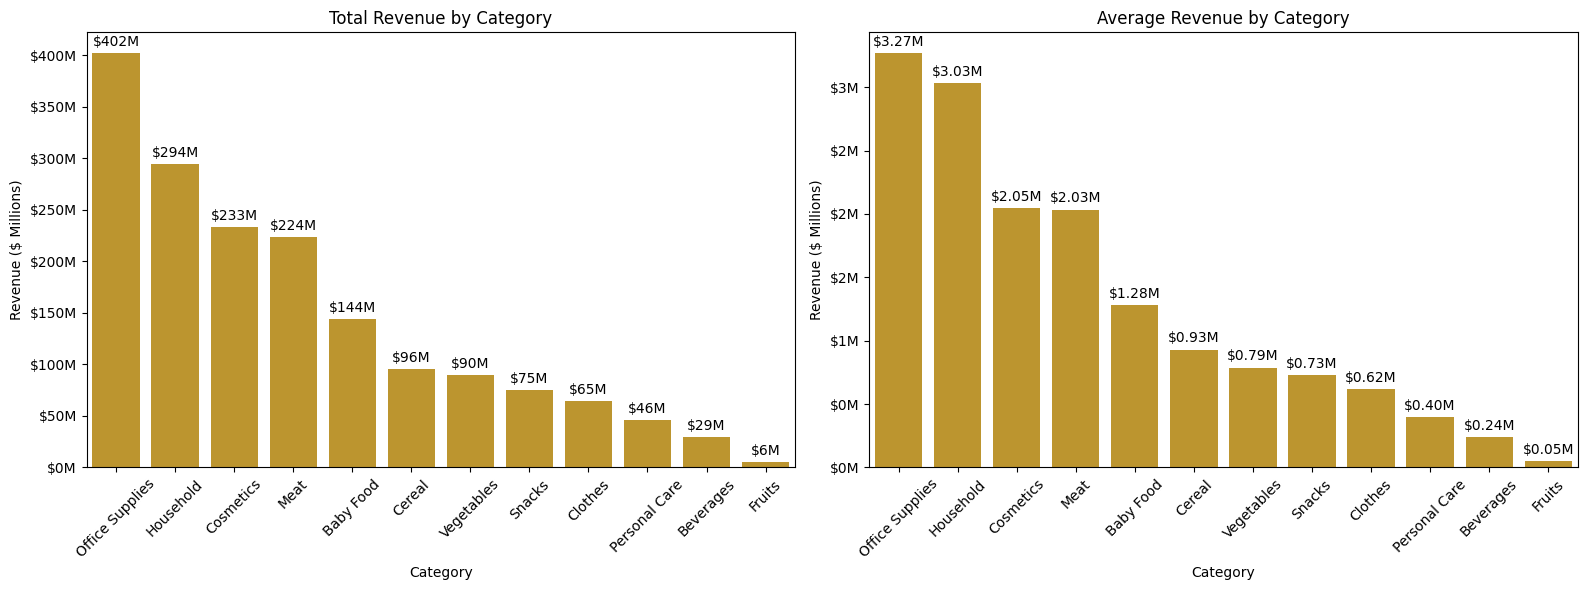

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total revenue by category
total_revenue = (
    df.groupby('category', as_index=False)['revenue']
      .sum()
      .sort_values('revenue', ascending=False))

ax1 = sns.barplot(
    data=total_revenue,
    x='category',
    y='revenue',
    color=REVENUE_COLOR,
    ax=axes[0])

ax1.yaxis.set_major_formatter(currency_formatter)

for container in ax1.containers:
    labels = [f'${v/1_000_000:.0f}M' for v in total_revenue['revenue']]
    ax1.bar_label(container, labels=labels, padding=3)

axes[0].set_title('Total Revenue by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Revenue ($ Millions)')
axes[0].tick_params(axis='x', rotation=45)

# Average revenue by category
avg_revenue = (
    df.groupby('category', as_index=False)['revenue']
      .mean()
      .sort_values('revenue', ascending=False))

ax2 = sns.barplot(
    data=avg_revenue,
    x='category',
    y='revenue',
    color=REVENUE_COLOR,
    ax=axes[1])

ax2.yaxis.set_major_formatter(currency_formatter)

for container in ax2.containers:
    labels = [f'${v/1_000_000:.2f}M' for v in avg_revenue['revenue']]
    ax2.bar_label(container, labels=labels, padding=3)

axes[1].set_title('Average Revenue by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Revenue ($ Millions)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

> Office Supplies generated the highest total revenue by a substantial margin, exceeding $400 million and significantly outperforming all other product categories. Household, Cosmetics, and Meat also contributed strongly to overall sales, forming the second tier of revenue-generating products. In contrast, Personal Care, Beverages, and Fruits generated relatively low revenue, indicating either lower demand, lower pricing, or a combination of both factors.

>The average revenue analysis largely mirrors the total revenue distribution, with Office Supplies and Household maintaining clear leadership positions. This suggests that their strong performance is not solely driven by sales volume but also by higher revenue generated per transaction. Categories such as Cosmetics and Meat demonstrate solid average revenue performance as well, while Fruits and Beverages remain the lowest-performing categories. The consistency between total and average revenue indicates a stable revenue structure across the product portfolio.



### 3.2.2. Profitability Analysis by Product Category

In [43]:
df.groupby("category")["profit"].agg(
    total_profit="sum",
    average_profit="mean",
    median_profit="median",
    transaction_count="count"
).sort_values("total_profit", ascending=False)

,total_profit,average_profit,median_profit,transaction_count
category,,,,
Cosmetics,"92,723,306.17","813,362.33","722,951.46",114
Office Supplies,"77,977,176.25","633,960.78","647,536.25",123
Household,"72,962,466.77","752,190.38","720,594.04",97
Baby Food,"53,940,997.16","481,616.05","492,480.75",112
Clothes,"43,431,314.40","413,631.57","436,527.36",105
Cereal,"41,255,034.15","400,534.31","394,048.32",103
Vegetables,"36,776,002.72","322,596.52","333,926.13",114
Meat,"30,337,736.00","275,797.60","277,048.20",110
Snacks,"27,027,422.40","262,402.16","264,065.46",103


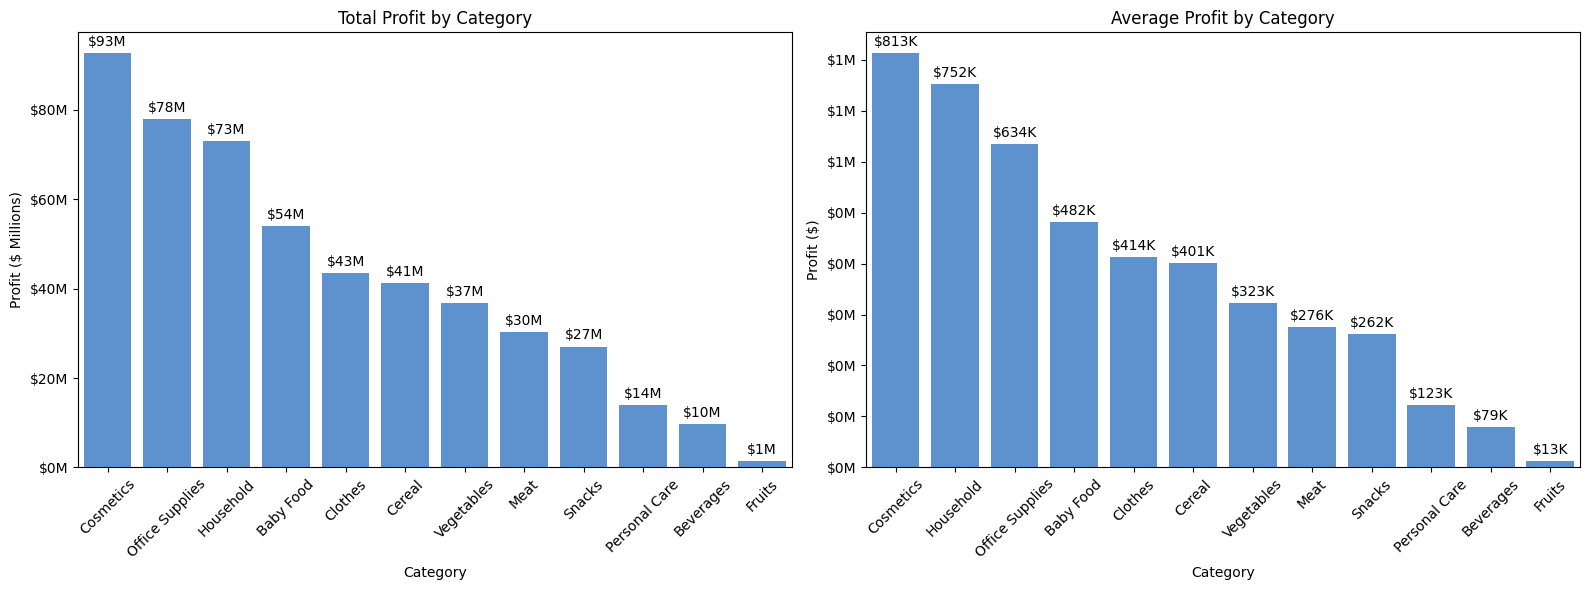

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total profit by category
total_profit = (
    df.groupby('category', as_index=False)['profit']
      .sum()
      .sort_values('profit', ascending=False))

ax1 = sns.barplot(
    data=total_profit,
    x='category',
    y='profit',
    color=PROFIT_COLOR,
    ax=axes[0])

ax1.yaxis.set_major_formatter(currency_formatter)

for container in ax1.containers:
    labels = [f'${v/1_000_000:.0f}M' for v in total_profit['profit']]
    ax1.bar_label(container, labels=labels, padding=3)

axes[0].set_title('Total Profit by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Profit ($ Millions)')
axes[0].tick_params(axis='x', rotation=45)

# Average profit by category
avg_profit = (
    df.groupby('category', as_index=False)['profit']
      .mean()
      .sort_values('profit', ascending=False))

ax2 = sns.barplot(
    data=avg_profit,
    x='category',
    y='profit',
    color=PROFIT_COLOR,
    ax=axes[1])

ax2.yaxis.set_major_formatter(currency_formatter)

for container in ax2.containers:
    labels = [f'${v/1000:.0f}K' for v in avg_profit['profit']]
    ax2.bar_label(container, labels=labels, padding=3)

axes[1].set_title('Average Profit by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Profit ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

> Profitability across product categories differs noticeably from the revenue distribution. Cosmetics emerged as the most profitable category, generating the highest total profit despite ranking behind Office Supplies in terms of revenue. Office Supplies and Household also delivered strong profitability, confirming their importance to overall business performance. Categories such as Personal Care, Beverages, and Fruits contributed only a small portion of total profit, suggesting limited profitability and lower financial impact compared to the leading categories.

> The average profit per transaction highlights Cosmetics and Household as the most efficient categories in terms of profit generation. While Office Supplies remains one of the strongest contributors overall, its average profit is lower than that of the top two categories, indicating that its success is driven more by sales volume. Baby Food and Clothes also demonstrate relatively high average profitability, whereas Fruits and Beverages generate minimal profit per transaction. These results suggest that some categories create value through high margins, while others depend primarily on sales volume to drive performance.

### 3.2.3. Category Popularity Analysis

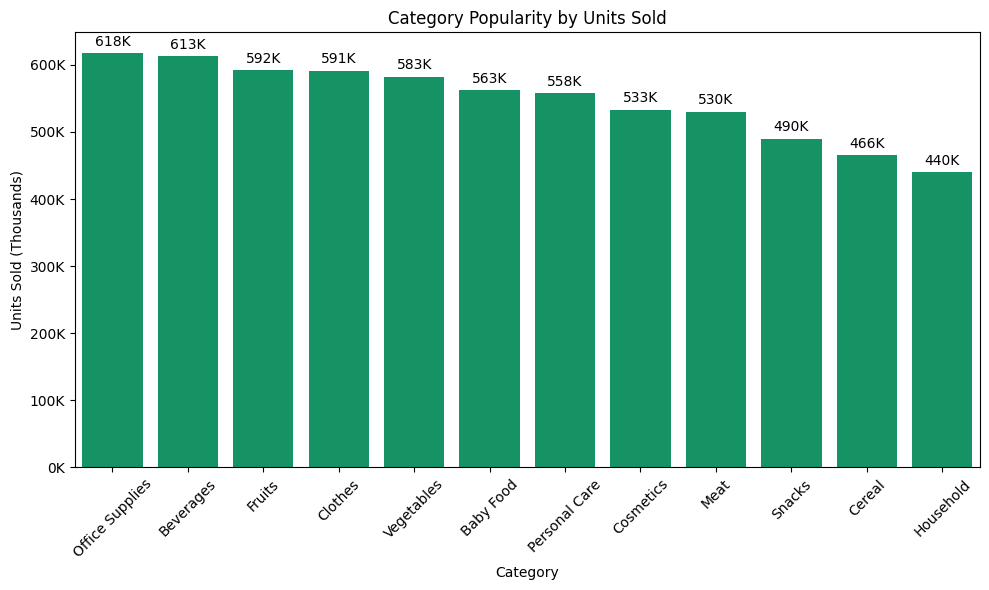

In [45]:
category_popularity = (
    df.groupby('category', as_index=False)['units_sold']
      .sum()
      .sort_values('units_sold', ascending=False))

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_popularity,
    x='category',
    y='units_sold',
    color=UNITS_COLOR)

ax.yaxis.set_major_formatter(thousands_formatter)

for container in ax.containers:
    labels = [
        f'{v/1000:.0f}K'
        for v in category_popularity['units_sold']]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=10)

plt.xticks(rotation=45)
plt.title('Category Popularity by Units Sold')
plt.xlabel('Category')
plt.ylabel('Units Sold (Thousands)')

plt.tight_layout()
plt.show()

> The distribution of units sold is considerably more balanced than the revenue and profit distributions. Office Supplies remains the most popular category in terms of sales volume, closely followed by Beverages and Fruits. Interestingly, several categories with relatively modest revenue and profit performance, such as Beverages and Fruits, rank among the highest in units sold. This suggests that these products are sold frequently but generate lower revenue and profit per transaction. In contrast, Household and Cereal appear near the bottom of the ranking despite performing well financially, indicating that their business value is driven by higher prices or margins rather than sales volume alone. Overall, the results reveal clear differences between product popularity and financial performance across categories.

### 3.2.4. Financial Performance by Country

In [46]:
country_metrics = (
    df.groupby('country', as_index=False)
      .agg(
          revenue=('revenue', 'sum'),
          total_cost=('total_cost', 'sum'),
          profit=('profit', 'sum'))
      .sort_values('revenue', ascending=False))

country_metrics.head()

,country,revenue,total_cost,profit
10,Czech Republic,"53,543,932.14","39,908,338.36","13,635,593.78"
43,Ukraine,"53,252,317.54","38,447,391.80","14,804,925.74"
6,Bosnia and Herzegovina,"50,117,508.49","36,859,905.72","13,257,602.77"
26,Macedonia,"49,222,085.25","35,537,985.30","13,684,099.95"
36,San Marino,"47,883,708.48","34,090,715.67","13,792,992.81"


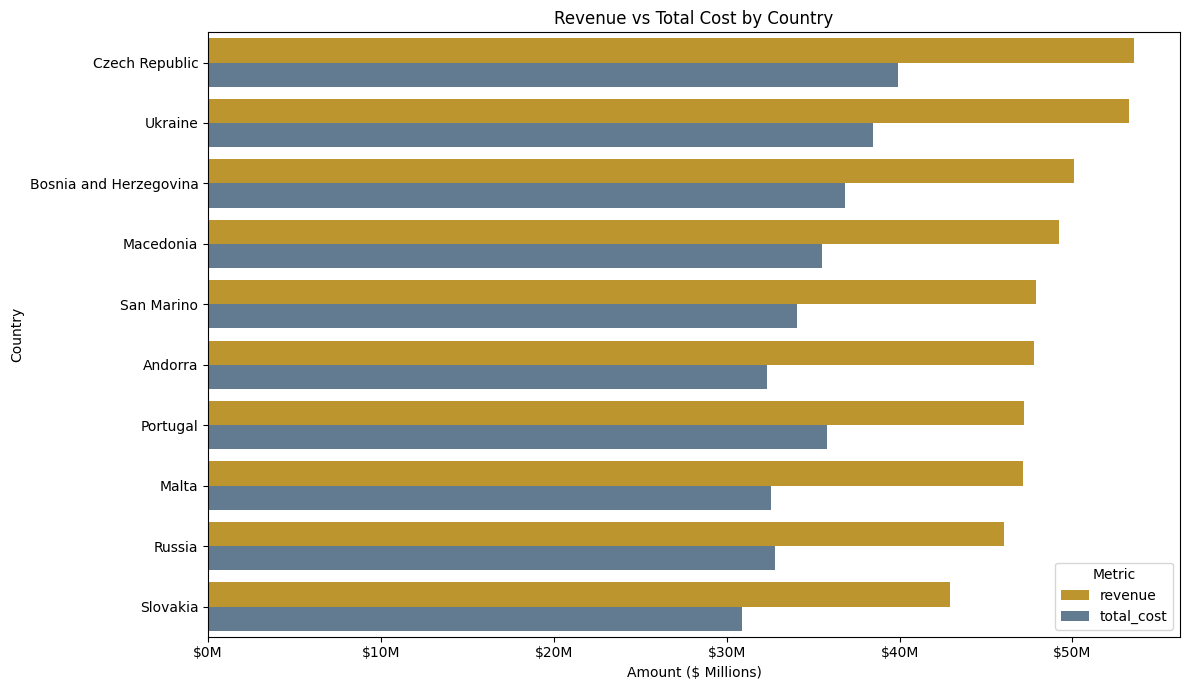

In [47]:
top10 = country_metrics.head(10)

country_plot_df = top10.melt(
    id_vars='country',
    value_vars=['revenue', 'total_cost'],
    var_name='metric',
    value_name='value')

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=country_plot_df,
    x='value',
    y='country',
    hue='metric',
    palette={
        'revenue': REVENUE_COLOR,
        'total_cost': COST_COLOR})

ax.xaxis.set_major_formatter(currency_formatter)

plt.title('Revenue vs Total Cost by Country')
plt.xlabel('Amount ($ Millions)')
plt.ylabel('Country')

plt.legend(title='Metric')

plt.tight_layout()
plt.show()

> The top-performing countries demonstrate a relatively consistent relationship between revenue and total cost, indicating a stable cost structure across major markets. The Czech Republic and Ukraine generated the highest revenue among the analyzed countries, followed closely by Bosnia and Herzegovina and Macedonia. While revenue levels vary slightly across countries, the gap between revenue and total cost remains substantial in all cases, suggesting healthy profitability and effective cost management. Additionally, no country appears to be operating with unusually high costs relative to revenue, which indicates balanced financial performance across the leading markets. The results suggest that business growth in these countries is driven by both strong sales volumes and sustainable margins rather than aggressive spending strategies.

### 3.2.5. Regional Financial Performance Analysis

In [48]:
region_metrics = (
    df.groupby('region', as_index=False)
      .agg(
          revenue=('revenue', 'sum'),
          total_cost=('total_cost', 'sum'),
          profit=('profit', 'sum'))
      .sort_values('revenue', ascending=False))

region_metrics.head()

,region,revenue,total_cost,profit
1,Europe,"1,505,652,873.89","1,057,096,091.78","448,556,782.11"
0,Asia,"93,330,887.37","68,178,634.42","25,152,252.95"


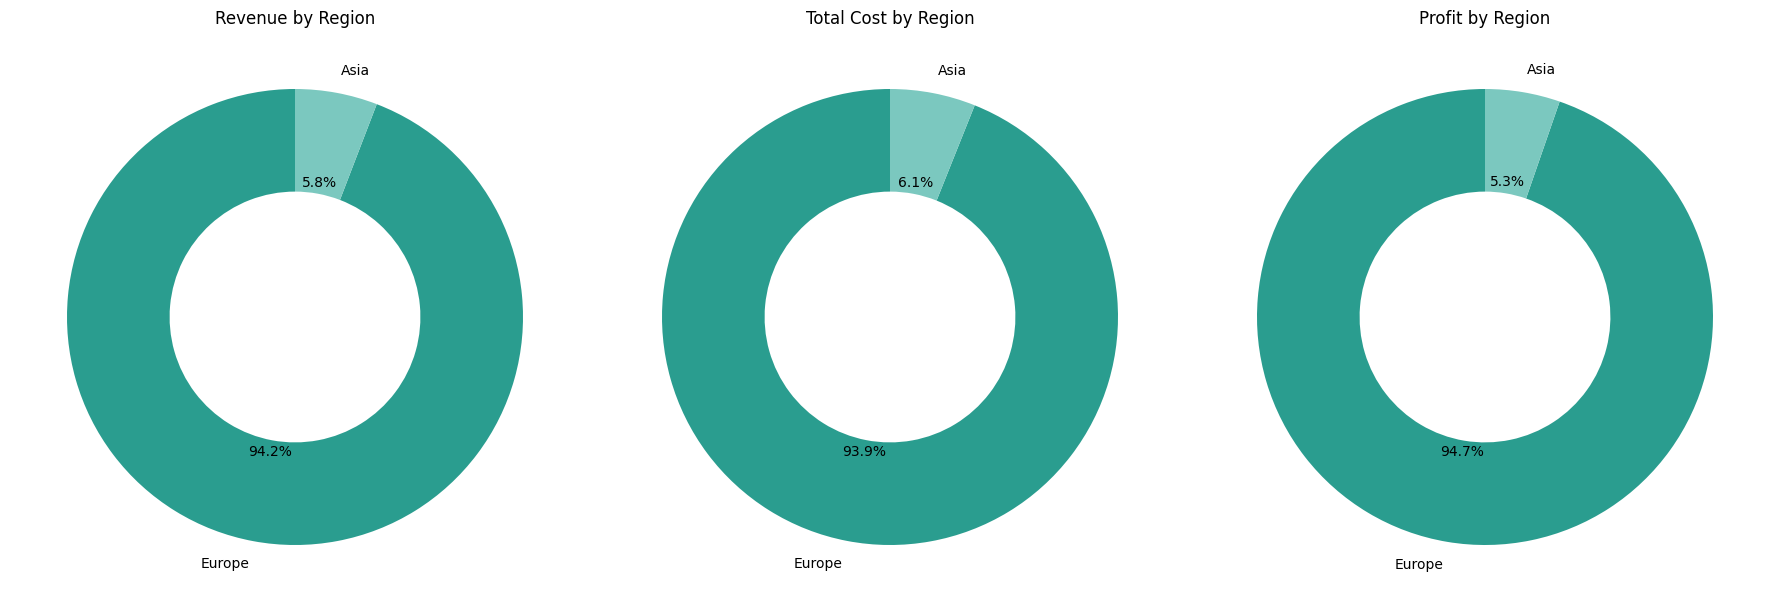

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

region_palette = [
    REGION_COLOR,
    '#7BC8BF']

# Revenue
axes[0].pie(
    region_metrics['revenue'],
    labels=region_metrics['region'],
    autopct='%1.1f%%',
    startangle=90,
    colors=region_palette,
    wedgeprops={'width': 0.45})
axes[0].set_title('Revenue by Region')

# Total Cost
axes[1].pie(
    region_metrics['total_cost'],
    labels=region_metrics['region'],
    autopct='%1.1f%%',
    startangle=90,
    colors=region_palette,
    wedgeprops={'width': 0.45})
axes[1].set_title('Total Cost by Region')

# Profit
axes[2].pie(
    region_metrics['profit'],
    labels=region_metrics['region'],
    autopct='%1.1f%%',
    startangle=90,
    colors=region_palette,
    wedgeprops={'width': 0.45})
axes[2].set_title('Profit by Region')

plt.tight_layout()
plt.show()

> The regional analysis reveals a highly concentrated business structure, with Europe accounting for approximately 94% of total revenue, total costs, and total profit, while Asia contributes only about 5-6% across all three financial indicators. The nearly identical distribution of revenue and costs suggests a consistent cost structure between regions, with no significant differences in operational efficiency. Europe also generates a slightly larger share of total profit (94.7%) than revenue (94.2%), indicating marginally stronger profitability compared to Asia. Overall, the results demonstrate that the company’s financial performance is overwhelmingly driven by the European market, making it the primary source of both sales and profit, while Asia currently represents a relatively small share of business activity and financial contribution.

### 3.2.6. Financial Performance by Sub-Region

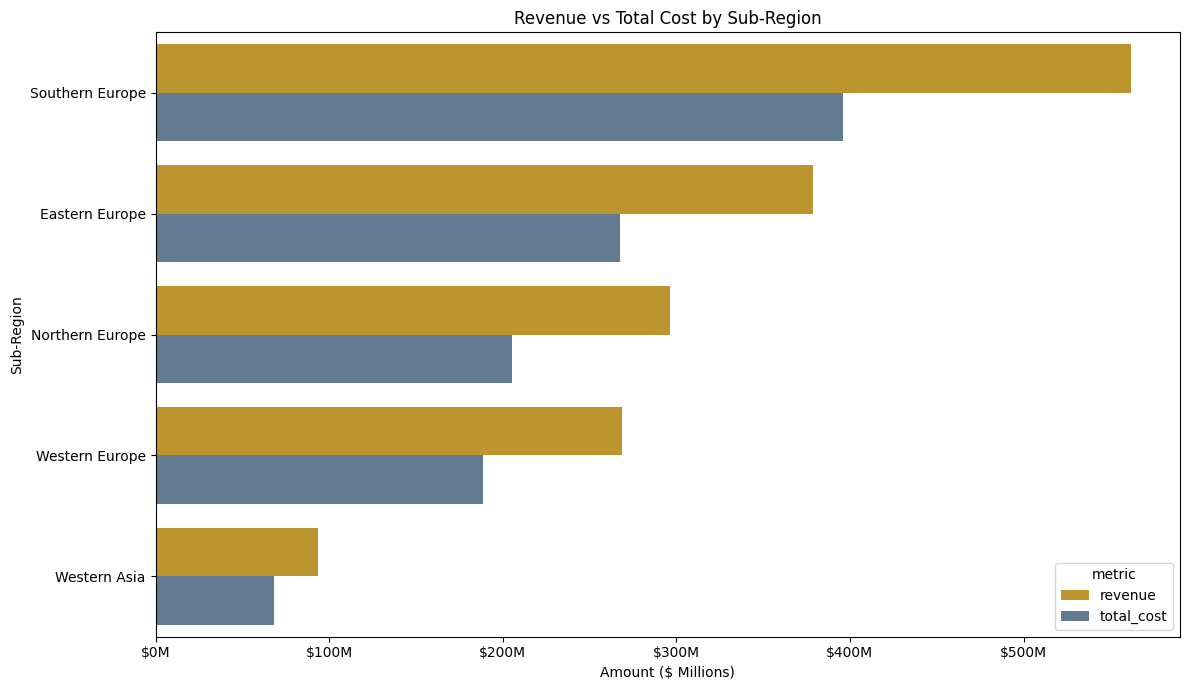

In [50]:
subregion_metrics = (
    df.groupby('sub_region', as_index=False)
      .agg(
          revenue=('revenue', 'sum'),
          total_cost=('total_cost', 'sum')
      )
      .sort_values('revenue', ascending=False))

subregion_plot_df = subregion_metrics.melt(
    id_vars='sub_region',
    value_vars=['revenue', 'total_cost'],
    var_name='metric',
    value_name='value')

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=subregion_plot_df,
    x='value',
    y='sub_region',
    hue='metric',
    palette={
        'revenue': REVENUE_COLOR,
        'total_cost': COST_COLOR})

ax.xaxis.set_major_formatter(currency_formatter)

plt.title('Revenue vs Total Cost by Sub-Region')
plt.xlabel('Amount ($ Millions)')
plt.ylabel('Sub-Region')


plt.tight_layout()
plt.show()

> The sub-regional analysis shows that Southern Europe is the dominant contributor to the business, generating the highest revenue and incurring the highest total costs by a considerable margin. Eastern Europe, Northern Europe, and Western Europe form a second tier of important markets, all demonstrating strong financial performance with relatively balanced cost structures. Western Asia contributes only a small share of total revenue and costs, indicating a much lower level of business activity compared to the European sub-regions. Across all sub-regions, the gap between revenue and total cost remains consistently positive, suggesting healthy profitability and efficient cost management. Overall, the results indicate that the company's financial success is largely concentrated in European markets, with Southern Europe serving as the primary driver of both sales and financial performance.

### 3.2.7. Sales Channel Performance Analysis

In [51]:
channel_metrics = (
    df.groupby('sales_channel', as_index=False)
      .agg(
          revenue=('revenue', 'sum'),
          total_cost=('total_cost', 'sum'),
          profit=('profit', 'sum'))
      .sort_values('revenue', ascending=False))

channel_metrics.head()

,sales_channel,revenue,total_cost,profit
0,Offline,"871,760,623.88","618,294,105.07","253,466,518.81"
1,Online,"830,368,784.33","582,400,844.14","247,967,940.19"


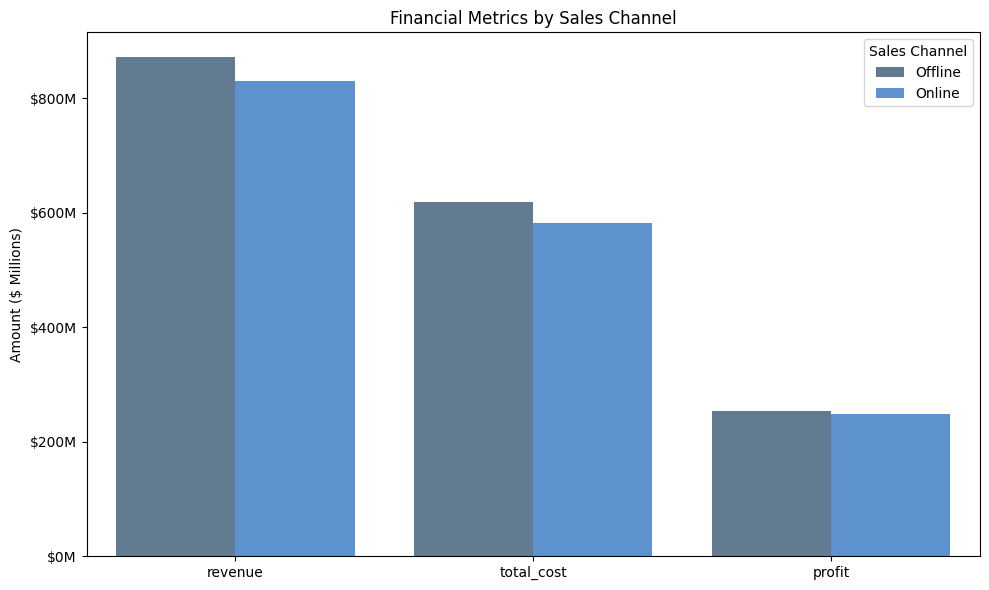

In [52]:
channel_plot_df = channel_metrics.melt(
    id_vars='sales_channel',
    value_vars=['revenue', 'total_cost', 'profit'],
    var_name='metric',
    value_name='value')

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=channel_plot_df,
    x='metric',
    y='value',
    hue='sales_channel',
    palette=['#5B7C99', '#4A90E2'])

ax.yaxis.set_major_formatter(currency_formatter)

plt.title('Financial Metrics by Sales Channel')
plt.xlabel('')
plt.ylabel('Amount ($ Millions)')

plt.legend(title='Sales Channel')

plt.tight_layout()
plt.show()

> The comparison between online and offline sales channels shows a remarkably balanced distribution across all key financial metrics. The offline channel slightly outperforms the online channel in revenue, total cost, and profit, indicating a modest advantage in overall financial contribution. However, the differences are relatively small, suggesting that both channels play an equally important role in generating business value. The similarity in revenue and profit levels also implies that the profitability structure is consistent across sales channels, with neither channel demonstrating a clear efficiency advantage. Overall, the results indicate a well-diversified sales strategy where both online and offline channels contribute significantly to revenue generation and profit growth, reducing dependence on a single distribution channel.

### 3.2.8. Sales Channel Popularity Analysis

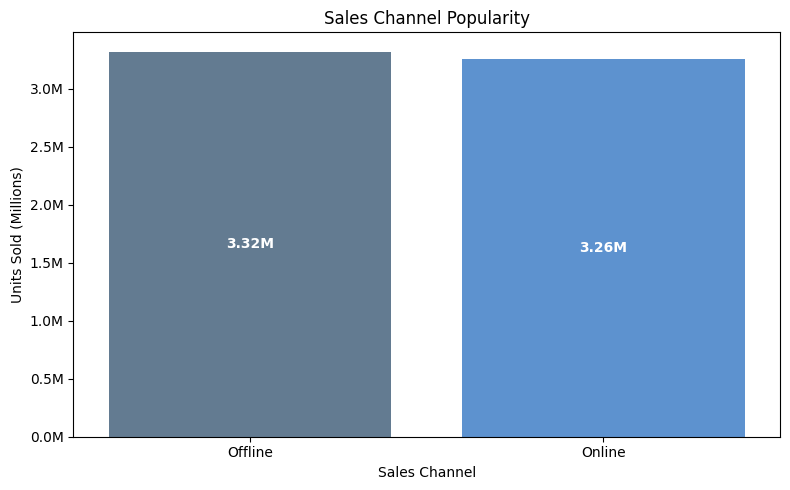

In [53]:
channel_popularity = (
    df.groupby('sales_channel', as_index=False)['units_sold']
      .sum()
      .sort_values('units_sold', ascending=False))

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=channel_popularity,
    x='sales_channel',
    y='units_sold',
    hue='sales_channel',
    palette={
        'Offline': '#5B7C99',
        'Online': '#4A90E2'},
    legend=False)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'{x/1_000_000:.1f}M'))

for container in ax.containers:
    labels = [
        f'{bar.get_height()/1_000_000:.2f}M'
        for bar in container]

    ax.bar_label(
        container,
        labels=labels,
        color='white',
        fontweight='bold',
        label_type='center')

plt.title('Sales Channel Popularity')
plt.xlabel('Sales Channel')
plt.ylabel('Units Sold (Millions)')

plt.tight_layout()
plt.show()


> Sales volume is distributed almost evenly between the two sales channels, indicating a well-balanced sales structure. The offline channel recorded approximately 3.32 million units sold, while the online channel followed closely with 3.26 million units sold. The difference between the channels is relatively small, representing less than 2% of total sales volume, which suggests that customer demand is consistently spread across both distribution channels. Combined with the previous financial analysis, these results indicate that neither channel dominates the business, and both offline and online sales contribute nearly equally to overall performance. Such a balanced distribution reduces operational risk and highlights the effectiveness of maintaining a multi-channel sales strategy.

### 3.2.9. Shipping Time Analysis by Product Category

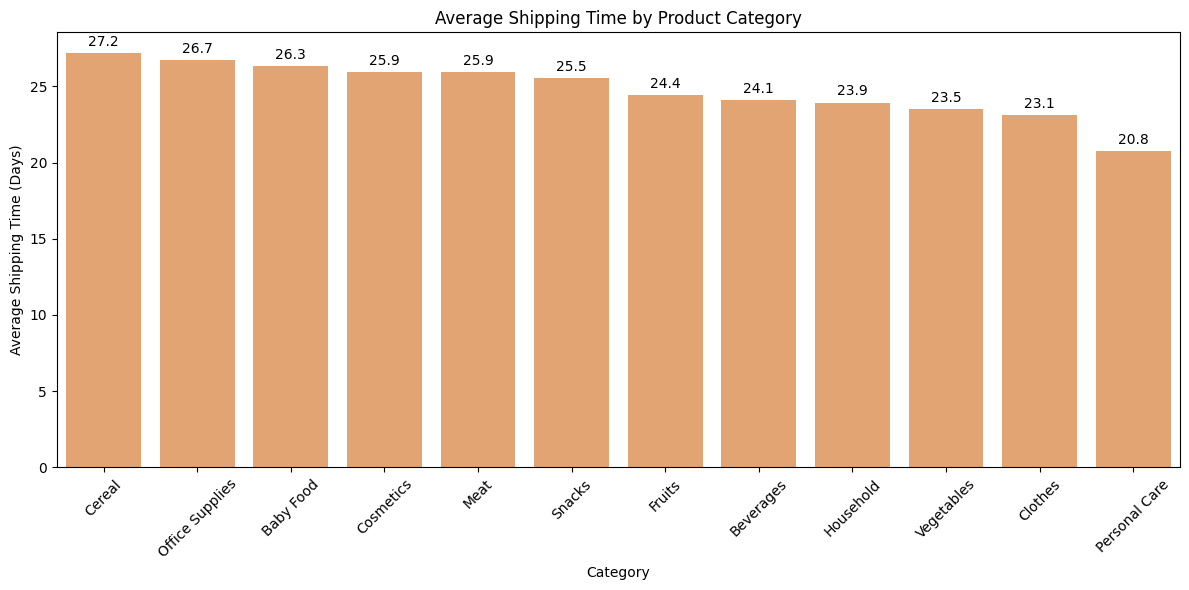

In [54]:
shipping_by_category = (
    df.groupby('category', as_index=False)['shipping_days']
      .mean()
      .sort_values('shipping_days', ascending=False))

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=shipping_by_category,
    x='category',
    y='shipping_days',
    color=SHIPPING_COLOR)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=3)

plt.xticks(rotation=45)
plt.title('Average Shipping Time by Product Category')
plt.xlabel('Category')
plt.ylabel('Average Shipping Time (Days)')

plt.tight_layout()
plt.show()

> The analysis shows a relatively consistent shipping performance across all product categories, with average delivery times ranging from 20.8 to 27.2 days. Cereal has the longest average shipping time (27.2 days), followed by Office Supplies (26.7 days) and Baby Food (26.3 days). On the other hand, Personal Care products are delivered the fastest, with an average shipping time of only 20.8 days, followed by Clothes (23.1 days) and Vegetables (23.5 days). Although there is a difference of approximately six days between the fastest and slowest categories, the overall distribution remains relatively stable, suggesting a well-managed logistics process. The results indicate that delivery efficiency is generally consistent across product groups, with only minor variations that may be related to product-specific handling, storage, or transportation requirements.

### 3.2.10. Average Shipping Time by Country

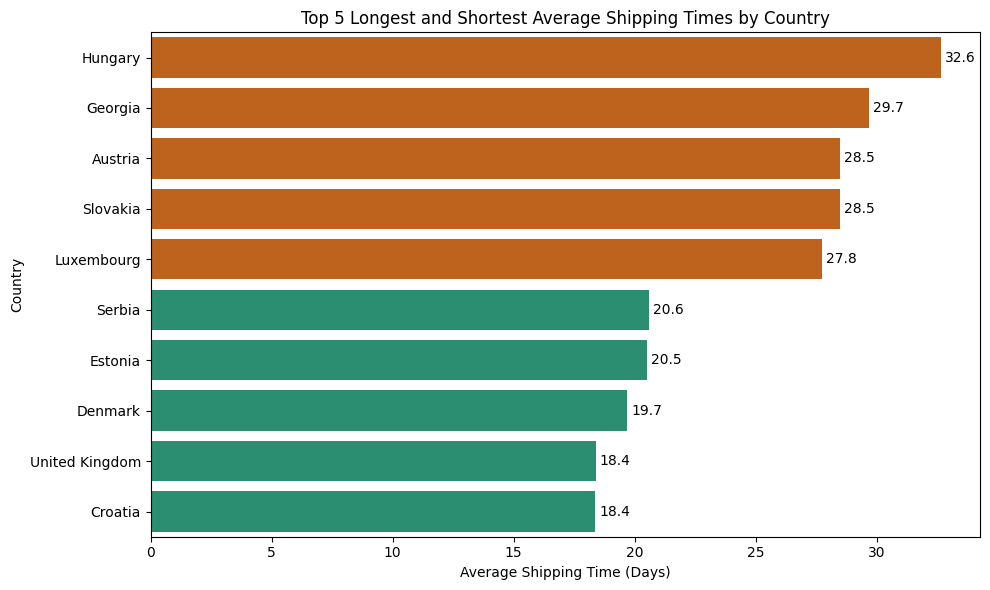

In [55]:
shipping_by_country = (
    df.groupby('country', as_index=False)['shipping_days']
      .mean()
      .sort_values('shipping_days', ascending=False))

top5 = shipping_by_country.head(5)
bottom5 = shipping_by_country.tail(5)

shipping_top_bottom = pd.concat([top5, bottom5])

# колір для кожної країни: помаранчевий для найдовших, зелений для найкоротших
color_map = {
    **{c: '#d95f02' for c in top5['country']},
    **{c: '#1b9e77' for c in bottom5['country']},
}

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=shipping_top_bottom,
    x='shipping_days',
    y='country',
    hue='country',      # те саме, що на осі y
    palette=color_map,  # словник замість списку
    legend=False)       # легенда дублювала б підписи осі

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=3)

plt.title(
    'Top 5 Longest and Shortest Average Shipping Times by Country')
plt.xlabel('Average Shipping Time (Days)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

> The analysis reveals considerable differences in average shipping performance across countries. Hungary, Georgia and Austria exhibit the longest average delivery times, exceeding 28 days, while Croatia, the United Kingdom and Denmark demonstrate the shortest shipping durations, below 20 days. This variation suggests that geographic and logistical factors significantly influence delivery performance and may represent opportunities for operational improvement in slower-performing markets.

### 3.2.11. Average Shipping Time by Region

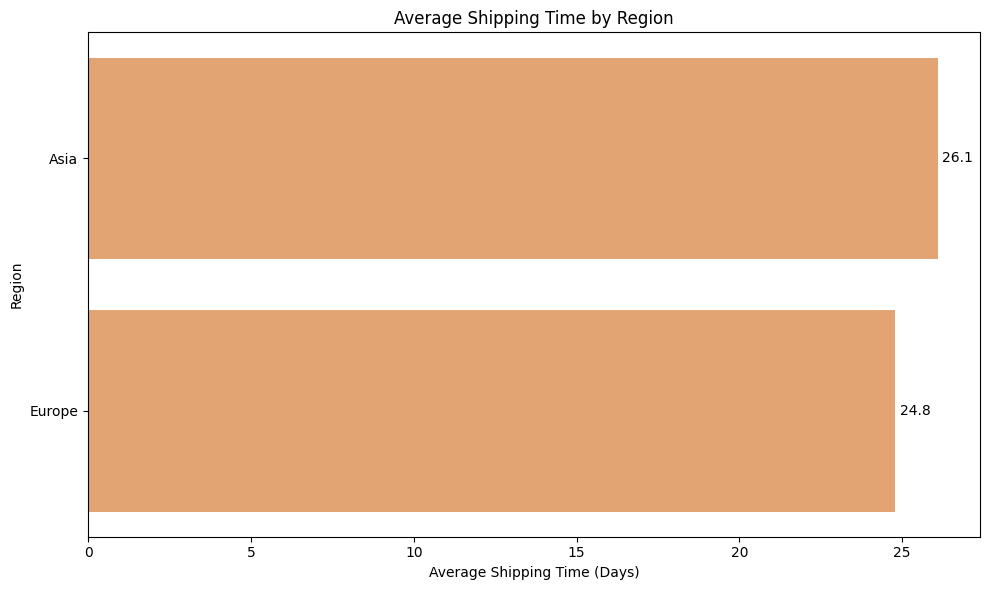

In [56]:
shipping_by_region = (
    df.groupby('region', as_index=False)['shipping_days']
      .mean()
      .sort_values('shipping_days', ascending=False))

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=shipping_by_region,
    x='shipping_days',
    y='region',
    color=SHIPPING_COLOR)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=3)

plt.title('Average Shipping Time by Region')
plt.xlabel('Average Shipping Time (Days)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

> Regional analysis indicates that shipments to Asia require more time on average than shipments within Europe. The average delivery time in Asia is 26.1 days compared to 24.8 days in Europe. Although the difference is relatively modest, it may reflect longer transportation routes, customs procedures, or regional logistics constraints.

### 3.2.12. Shipping Time Analysis by Sub-Region

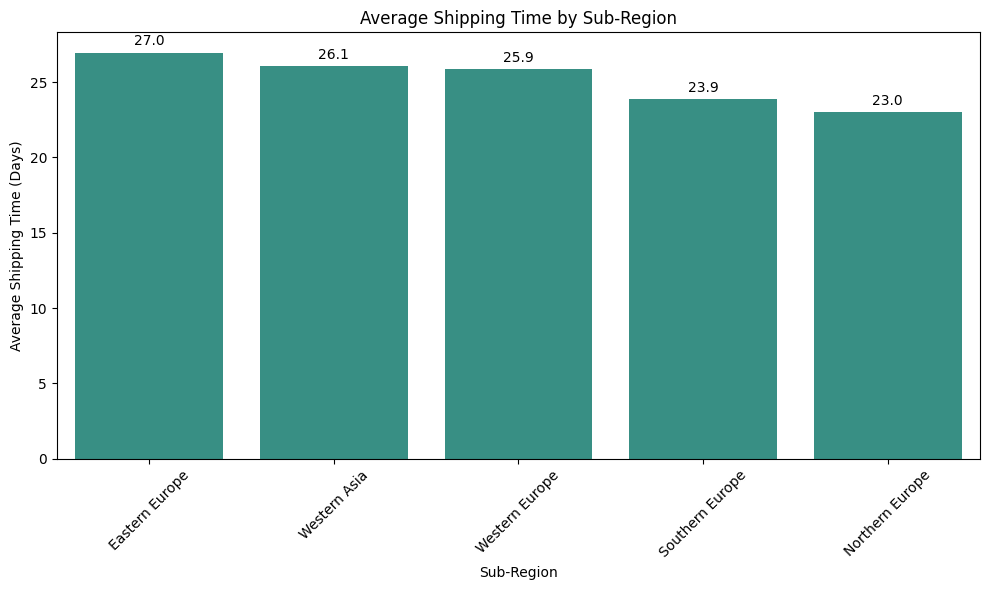

In [57]:
shipping_by_subregion = (
    df.groupby('sub_region', as_index=False)['shipping_days']
      .mean()
      .sort_values('shipping_days', ascending=False))

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=shipping_by_subregion,
    x='sub_region',
    y='shipping_days',
    color=REGION_COLOR)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.xticks(rotation=45)
plt.title('Average Shipping Time by Sub-Region')
plt.xlabel('Sub-Region')
plt.ylabel('Average Shipping Time (Days)')

plt.tight_layout()
plt.show()

> The sub-regional analysis reveals moderate differences in delivery performance across geographic areas, with average shipping times ranging from 23.0 to 27.0 days. Eastern Europe records the longest average shipping time at 27.0 days, closely followed by Western Asia (26.1 days) and Western Europe (25.9 days). In contrast, Northern Europe demonstrates the fastest delivery performance with an average shipping time of 23.0 days, while Southern Europe also maintains relatively efficient shipping operations at 23.9 days. Although the gap between the fastest and slowest sub-regions is approximately four days, the overall variation remains limited, indicating a stable and well-coordinated logistics network. The results suggest that geographic location has a measurable but not substantial impact on delivery times, with most sub-regions maintaining similar service levels and operational efficiency.

### 3.2.13. Shipping Time and Profit Relationship

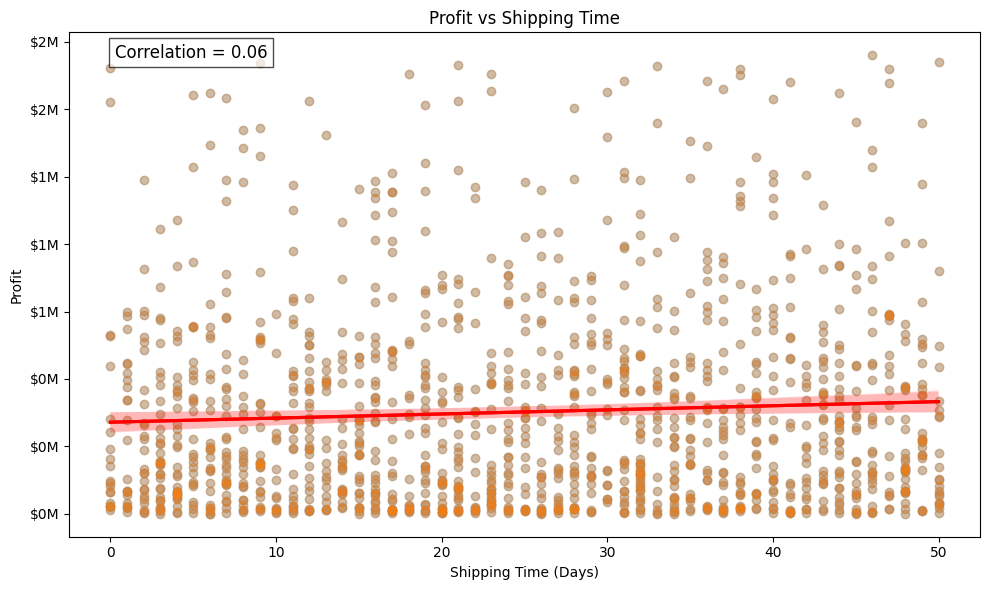

In [58]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='shipping_days',
    y='profit',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'})

ax = sns.regplot(
    data=df,
    x='shipping_days',
    y='profit',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'})

ax.yaxis.set_major_formatter(currency_formatter)

corr = df['shipping_days'].corr(df['profit'])

plt.text(
    0.05,
    0.95,
    f'Correlation = {corr:.2f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.7))

plt.title('Profit vs Shipping Time')
plt.xlabel('Shipping Time (Days)')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()

> The transaction-level scatter plot indicates only a weak positive relationship between shipping time and profit. Although the regression line shows a slight upward trend, profit values remain highly dispersed across all delivery durations. This suggests that shipping time alone is not a strong driver of profitability, and other business factors such as product category, order volume, or customer segment likely have a greater impact on profit generation.


### 3.2.14. Sales Trends by Product Category

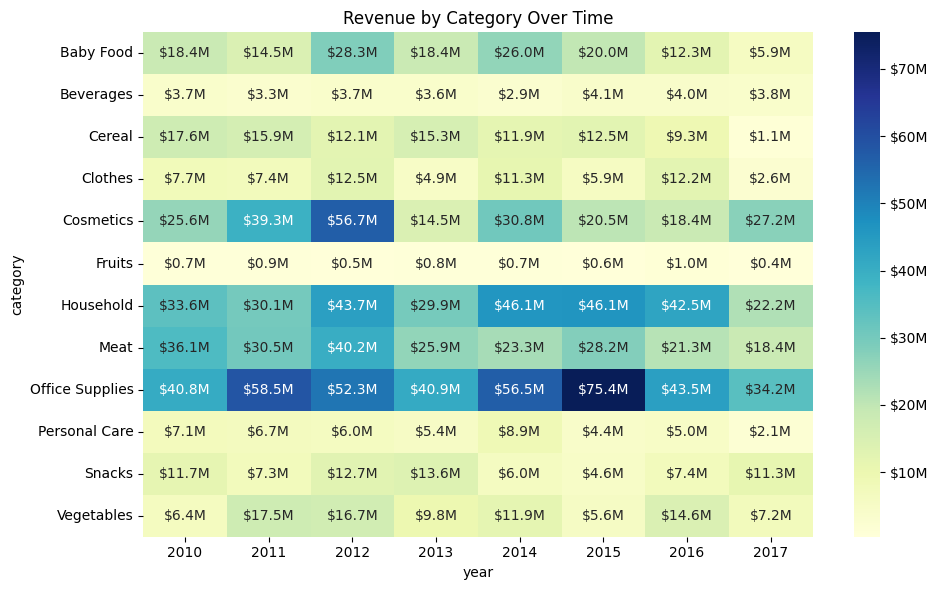

In [59]:
pivot = df.pivot_table(
    values='revenue',
    index='category',
    columns='year',
    aggfunc='sum')

annot_labels = pivot.map(
    lambda x: f'${x/1_000_000:.1f}M')

plt.figure(figsize=(10, 6))

ax = sns.heatmap(
    pivot,
    annot=annot_labels,
    fmt='',
    cmap='YlGnBu')

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(currency_formatter)

plt.title('Revenue by Category Over Time')

plt.tight_layout()
plt.show()

> The heatmap reveals that Office Supplies consistently generated the highest revenue throughout the analyzed period and remained the dominant product category in most years. Revenue peaked in 2015, reaching approximately $75.4 million, making it the strongest annual performance among all categories. Household, Meat, and Cosmetics also demonstrated strong and relatively stable revenue generation over time, forming the second tier of high-performing categories. In contrast, Fruits, Beverages, and Personal Care consistently produced the lowest revenue levels, contributing only a small share of total sales throughout the period. A noticeable pattern across many categories is the decline in revenue observed in 2017, suggesting either reduced sales activity or a shorter reporting period. Overall, the results indicate that the company's revenue is concentrated in a small number of core product categories, while lower-performing categories contribute relatively little to total revenue.

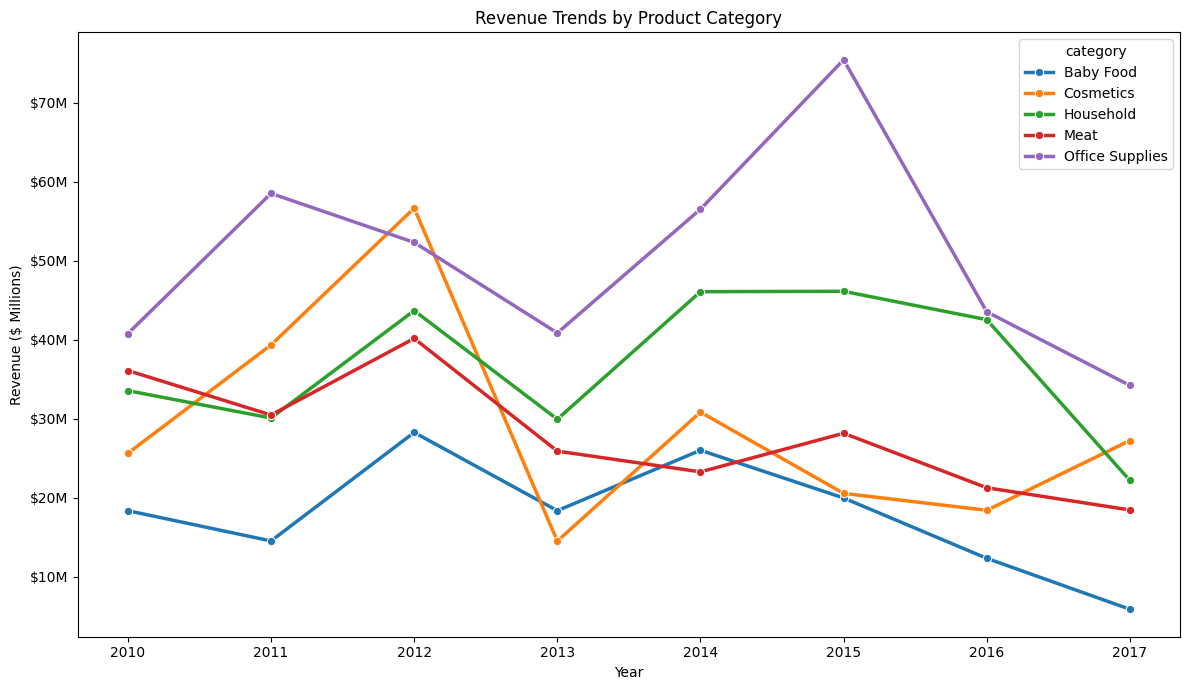

In [60]:
category_trends = (
    df.groupby(['year', 'category'])['revenue']
      .sum()
      .reset_index())

top_categories = (
    df.groupby('category')['revenue']
      .sum()
      .nlargest(5)
      .index)

category_trends = (
    category_trends[
        category_trends['category'].isin(top_categories)])

plt.figure(figsize=(12, 7))

ax = sns.lineplot(
    data=category_trends,
    x='year',
    y='revenue',
    hue='category',
    marker='o',
    linewidth=2.5)

ax.yaxis.set_major_formatter(currency_formatter)

plt.title('Revenue Trends by Product Category')
plt.xlabel('Year')
plt.ylabel('Revenue ($ Millions)')

plt.tight_layout()
plt.show()

> While the heatmap provides a compact overview of revenue intensity across categories and years, the line chart makes temporal trends and year-to-year fluctuations significantly easier to interpret.

>The line chart provides a clearer view of revenue dynamics over time for the five highest-performing product categories. Consistent with the heatmap analysis, Office Supplies remained the dominant category throughout the entire period, reaching its highest revenue of approximately \$75 million in 2015 before declining in subsequent years. Household products formed the second strongest category, maintaining relatively stable revenue levels between \$30–46 million across most years.
Cosmetics exhibited the highest volatility, increasing sharply to approximately \$57 million in 2012, dropping significantly in 2013, and then partially recovering before declining again. Meat and Baby Food showed moderate fluctuations over time but generally followed a downward trend after their peak years. A common pattern across nearly all categories is the revenue decline observed in 2017, which may indicate reduced sales activity, changing market conditions, or a shorter reporting period.
Overall, the chart confirms the findings highlighted by the heatmap: revenue is heavily concentrated in a small number of product categories, with Office Supplies consistently outperforming all competitors, while several categories experience substantial year-to-year fluctuations rather than steady long-term growth.

### 3.2.15. Sales Trends by Country

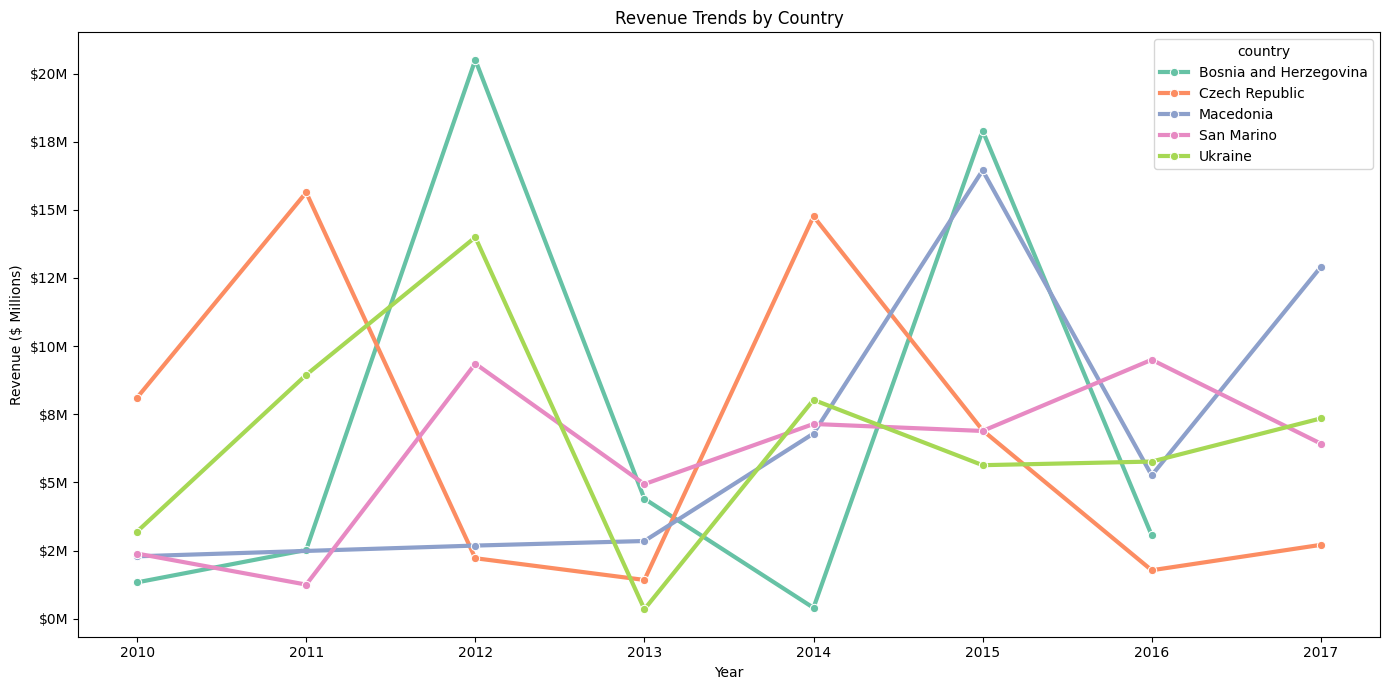

In [61]:
top_countries = (
    df.groupby('country')['revenue']
      .sum()
      .nlargest(5)
      .index)

country_trends = (
    df[df['country'].isin(top_countries)]
      .groupby(['year', 'country'])['revenue']
      .sum()
      .reset_index())

plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=country_trends,
    x='year',
    y='revenue',
    hue='country',
    palette='Set2',
    marker='o',
    linewidth=3)

ax.yaxis.set_major_formatter(currency_formatter)

plt.title('Revenue Trends by Country')
plt.xlabel('Year')
plt.ylabel('Revenue ($ Millions)')

plt.tight_layout()
plt.show()

> The revenue trends of the top five countries reveal considerable year-to-year fluctuations rather than a consistent pattern of growth or decline. Bosnia and Herzegovina and Macedonia exhibit the highest volatility, experiencing sharp revenue spikes in specific years followed by significant declines. Ukraine demonstrates the most stable performance among the leading countries, maintaining relatively consistent revenue levels throughout the analyzed period. Several countries reached their highest revenue values between 2012 and 2015, suggesting a period of particularly strong sales activity across major markets. However, no country shows uninterrupted growth over time, indicating that demand and sales performance vary substantially from year to year. Overall, the results suggest that revenue generation is influenced by periodic sales surges rather than long-term linear growth, highlighting the importance of monitoring individual market performance over time.

### 3.2.16. Sales Trends by Sub-Region

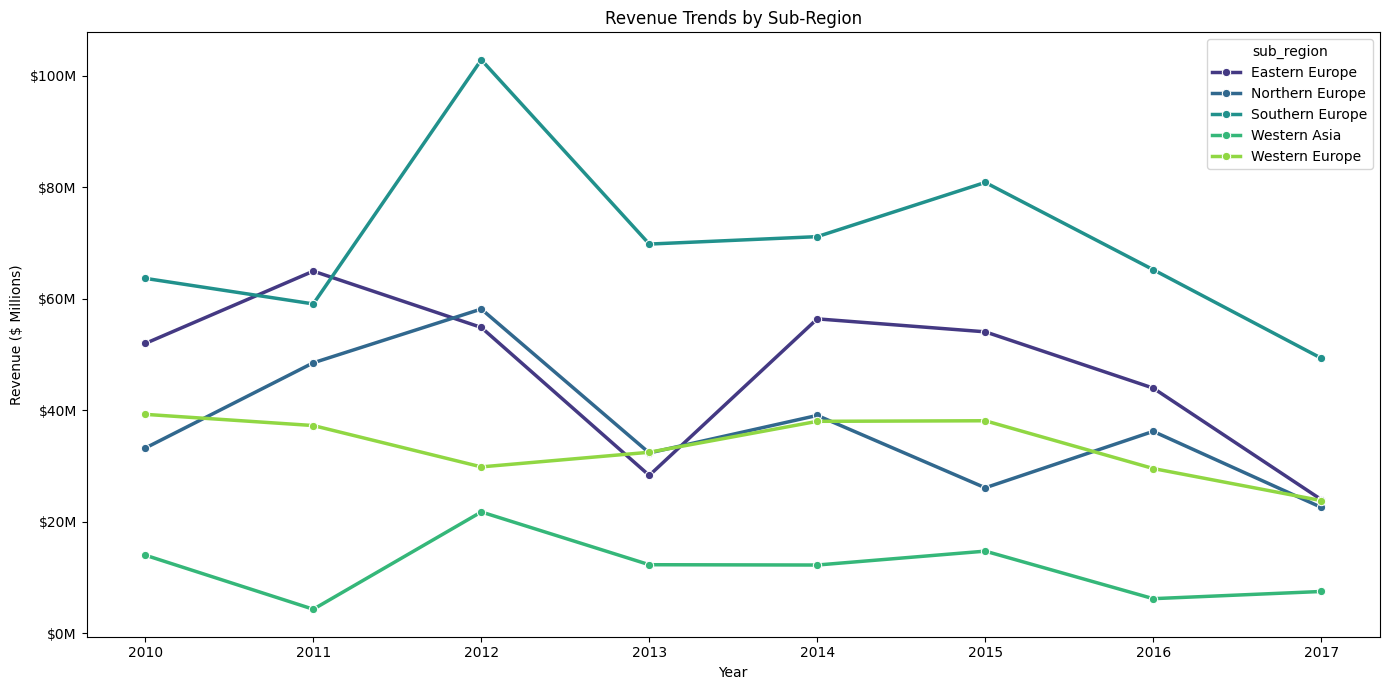

In [62]:
subregion_trends = (
    df.groupby(['year', 'sub_region'])['revenue']
      .sum()
      .reset_index())

plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=subregion_trends,
    x='year',
    y='revenue',
    hue='sub_region',
    palette='viridis',
    marker='o',
    linewidth=2.5)

ax.yaxis.set_major_formatter(currency_formatter)

plt.title('Revenue Trends by Sub-Region')
plt.xlabel('Year')
plt.ylabel('Revenue ($ Millions)')

plt.tight_layout()
plt.show()

> The revenue trends reveal that Southern Europe consistently outperformed all other sub-regions throughout the analyzed period, making it the primary driver of sales revenue. The region experienced a significant peak in 2012, exceeding $100 million, and maintained strong performance in subsequent years despite some fluctuations. Eastern Europe and Northern Europe formed a second group of major contributors, both generating substantial revenue but exhibiting noticeably higher volatility. In particular, Eastern Europe experienced pronounced fluctuations, including strong peaks in 2011, 2014, and 2015 followed by periods of decline. Western Europe maintained relatively stable revenue levels over time, while Western Asia consistently generated the lowest revenue and remained a comparatively small market throughout the period. Across most sub-regions, revenue declined in 2017, mirroring the pattern observed in the category analysis. Overall, the results suggest that the company's revenue is heavily concentrated in Southern Europe, while the remaining sub-regions play supporting but still important roles in overall business performance.

### 3.2.17. Sales Trends by Region

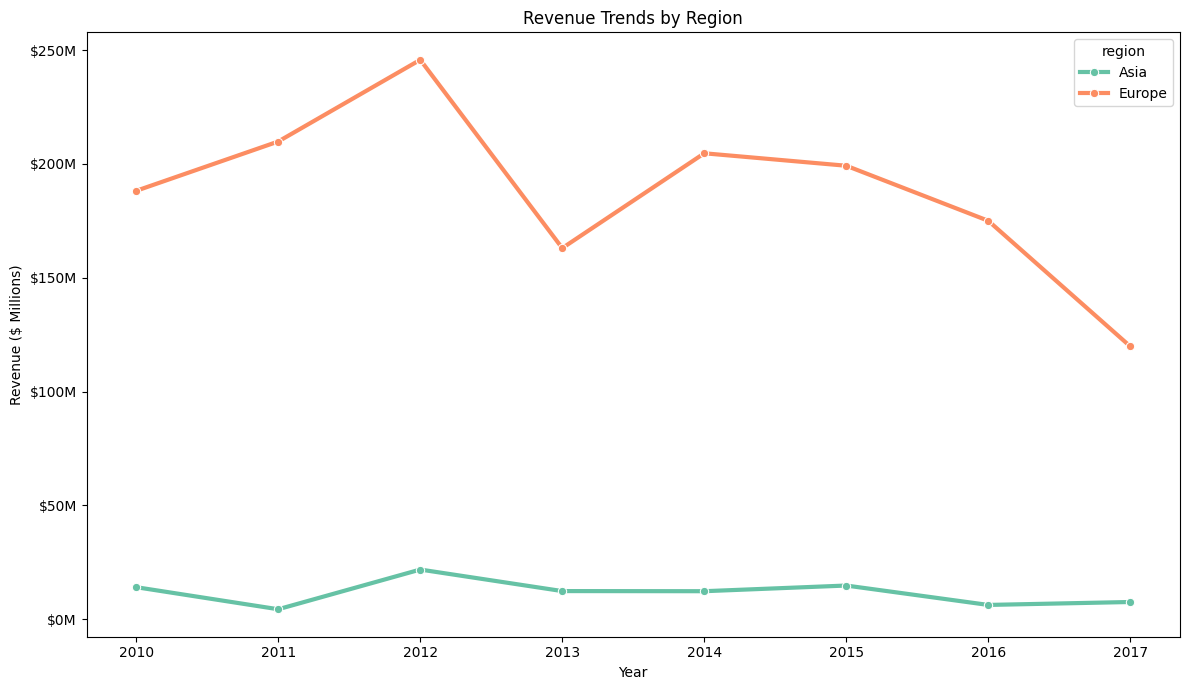

In [63]:
region_trends = (
    df.groupby(['year', 'region'])['revenue']
      .sum()
      .reset_index())

plt.figure(figsize=(12, 7))

ax = sns.lineplot(
    data=region_trends,
    x='year',
    y='revenue',
    hue='region',
    palette='Set2',
    marker='o',
    linewidth=3)

ax.yaxis.set_major_formatter(currency_formatter)

plt.title('Revenue Trends by Region')
plt.xlabel('Year')
plt.ylabel('Revenue ($ Millions)')

plt.tight_layout()
plt.show()

>The regional analysis reveals that Europe consistently generates substantially higher revenue than Asia throughout the observed period. Revenue in Europe peaked in 2012 at approximately $250 million before declining sharply in 2013 and continuing a gradual downward trend through 2017. In contrast, Asia shows a more stable performance with relatively modest fluctuations over time. Overall, Europe remains the primary revenue-generating region, while Asia contributes a smaller but more consistent share of total revenue.

### 3.2.18. Sales Performance by Day of Week

In [64]:
df['weekday'] = df['order_date'].dt.day_name()

In [65]:
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday']

In [66]:
weekday_sales = (
    df.groupby('weekday', as_index=False)['revenue']
      .sum())

weekday_sales['weekday'] = pd.Categorical(
    weekday_sales['weekday'],
    categories=weekday_order,
    ordered=True)

weekday_sales = weekday_sales.sort_values('weekday')

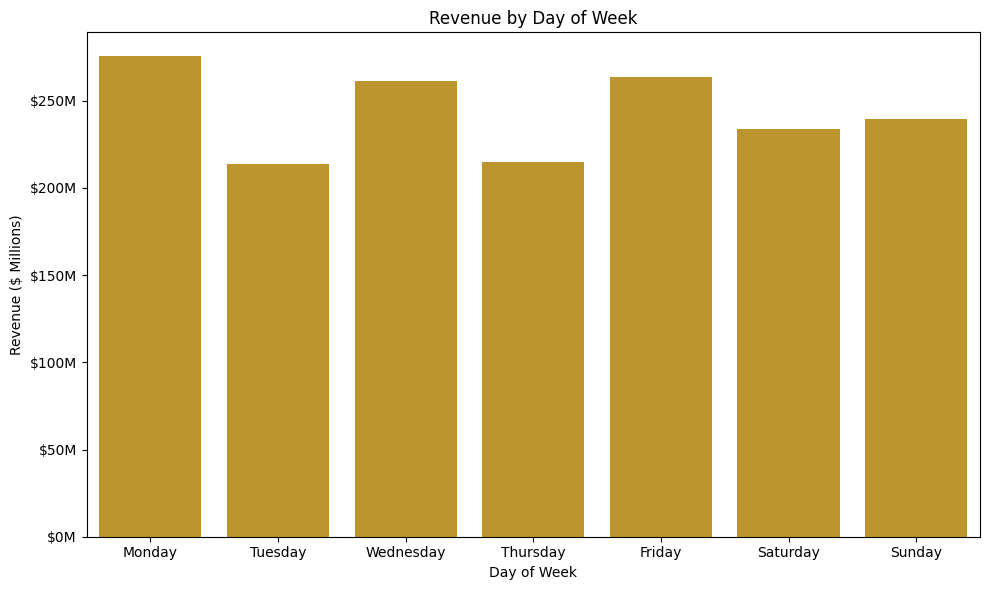

In [67]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=weekday_sales,
    x='weekday',
    y='revenue',
    color=REVENUE_COLOR)

ax.yaxis.set_major_formatter(currency_formatter)

plt.title('Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue ($ Millions)')

plt.tight_layout()
plt.show()

> The day-of-week analysis indicates a fairly balanced distribution of revenue throughout the week, with no evidence of strong weekly seasonality. Monday generated the highest revenue, reaching approximately \$277 million, while Friday and Wednesday followed closely behind. Tuesday and Thursday recorded the lowest revenue levels, although the difference between the strongest and weakest days represents only about $60 million, which is relatively modest given the overall sales volume. Weekend performance remained comparable to weekdays, suggesting that customer demand is consistently distributed across the entire week rather than concentrated on specific days. Overall, the results indicate that sales activity remains stable regardless of the day of the week, with only minor fluctuations in revenue generation.

### 3.2.19. Weekly Sales Patterns by Product Category

In [68]:
category_weekday = pd.pivot_table(
    df,
    values='revenue',
    index='category',
    columns='weekday',
    aggfunc='sum')

category_weekday = category_weekday[
    weekday_order]

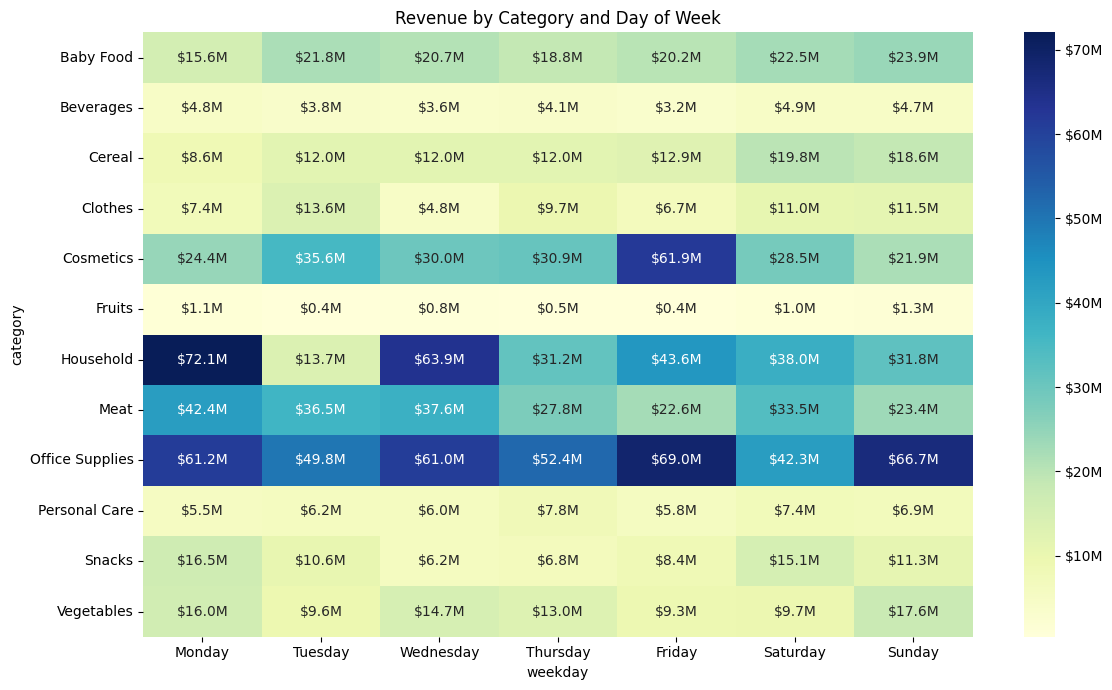

In [69]:
plt.figure(figsize=(12, 7))

annot_labels = category_weekday.map(
    lambda x: f'${x/1_000_000:.1f}M')

ax = sns.heatmap(
    category_weekday,
    annot=annot_labels,
    fmt='',
    cmap='YlGnBu')

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(currency_formatter)

plt.title('Revenue by Category and Day of Week')

plt.tight_layout()
plt.show()

> The heatmap indicates that most product categories generate revenue relatively consistently throughout the week, suggesting limited weekly seasonality. However, several categories exhibit noticeable peaks on specific days. Cosmetics show a significant revenue spike on Friday (approximately \$61.9 million), making Friday the strongest sales day for this category by a substantial margin. Household products perform exceptionally well on Monday (\$72.1 million) and remain strong on Wednesday, while Office Supplies maintain high revenue levels throughout the entire week and reach their highest sales on Friday (\$69.0 million) and Sunday (\$66.7 million). Meat products generate their strongest revenue on Monday, whereas categories such as Beverages, Fruits, and Personal Care display only minor fluctuations across weekdays. Overall, the analysis suggests that revenue patterns are generally stable, but Cosmetics, Household, and Office Supplies demonstrate partial weekly seasonality due to clearly identifiable sales peaks on particular days. These categories may benefit from targeted promotional campaigns and inventory planning aligned with their strongest sales periods.

>Although the dataset does not reveal strong seasonality across all product categories, several categories show evidence of weekly seasonal behavior. In particular, Cosmetics, Household, and Office Supplies experience pronounced revenue peaks on specific weekdays, indicating recurring purchasing patterns. Conversely, categories such as Beverages, Fruits, and Personal Care maintain relatively uniform sales levels throughout the week, suggesting stable demand with little or no weekly seasonality. Therefore, certain categories can be considered moderately seasonal on a weekly basis, while the overall sales structure remains relatively balanced across the seven days of the week.

### 3.2.20. Monthly Sales Trends

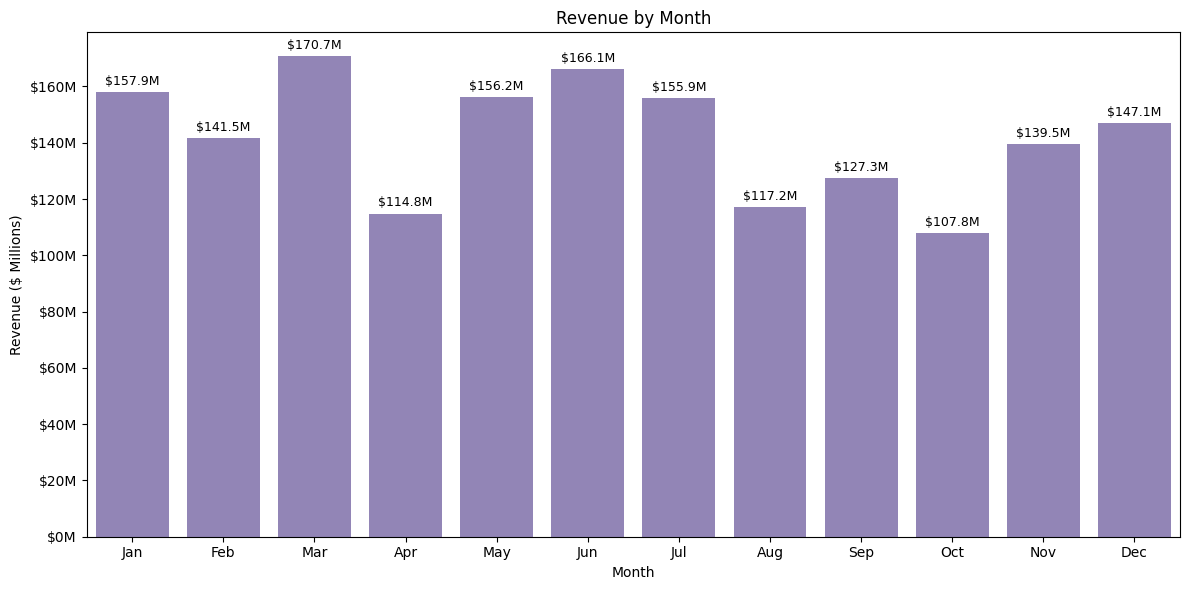

In [70]:
monthly_sales = (
    df.groupby('month', as_index=False)['revenue']
      .sum()
      .sort_values('month'))

month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar',
    4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep',
    10: 'Oct', 11: 'Nov', 12: 'Dec'}

monthly_sales['month_name'] = monthly_sales['month'].map(month_names)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=monthly_sales,
    x='month_name',
    y='revenue',
    color=TIME_COLOR)

ax.yaxis.set_major_formatter(currency_formatter)

for container in ax.containers:
    labels = [
        f'${v/1_000_000:.1f}M'
        for v in monthly_sales['revenue']]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9)

plt.title('Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue ($ Millions)')

plt.tight_layout()
plt.show()

> The monthly sales analysis reveals noticeable fluctuations in revenue throughout the year, indicating moderate seasonal patterns. March generated the highest revenue, reaching approximately \$170.7 million, closely followed by June (\$166.1 million), January (\$157.9 million), and May (\$156.2 million). Revenue remained relatively strong during the first half of the year, suggesting increased sales activity during this period. In contrast, October recorded the weakest performance with approximately \$107.8 million, while April (\$114.8 million) and August (\$117.2 million) also experienced lower revenue levels. Revenue began to recover during the final quarter, with November and December showing renewed growth. Overall, the results suggest the presence of seasonal demand patterns, with stronger sales concentrated in the first half of the year and a temporary slowdown during late summer and early autumn before recovering toward year-end.


> Unlike the weekday analysis, which showed relatively stable sales performance across the week, the monthly analysis indicates a clearer seasonal effect. The substantial difference of more than $60 million between the strongest month (March) and the weakest month (October) suggests that customer demand varies throughout the year. This pattern may reflect purchasing cycles, promotional activities, inventory planning, or broader market trends that influence sales performance over longer time periods.

# 4. Conclusions

> This analysis provided a comprehensive evaluation of the company’s sales performance, profitability, logistics efficiency, geographic distribution, and seasonal patterns. The dataset includes 1,328 orders, covering 45 countries and 12 product categories, with total revenue of \$1.70 billion, total profit of \$501.4 million, and a profit margin of 29.5%.
Product performance is concentrated within a few key categories. Office Supplies generated more than \$400 million in revenue, making it the strongest revenue contributor, while Cosmetics achieved the highest overall profitability. Geographic analysis revealed a strong dependence on the European market, which accounted for approximately 94% of total revenue, costs, and profit, while Asia contributed only 5–6%. Southern Europe consistently acted as the primary revenue-generating sub-region.
Sales were evenly distributed across channels, with 3.32 million units sold offline and 3.26 million units sold online, indicating a balanced multi-channel strategy. Logistics performance also remained stable, with average shipping times ranging from 20.8 days to 27.2 days across product categories and an overall average of 24.8 days. The relationship between shipping time and profit was weak, suggesting that profitability is driven primarily by product mix, pricing, and sales volume rather than delivery duration.
Temporal analysis revealed limited weekly seasonality but stronger monthly variation. Revenue peaked in March (\$170.7 million) and reached its lowest level in October (\$107.8 million), a difference of more than $60 million, indicating noticeable seasonal fluctuations in customer demand.
Overall, the company demonstrates strong profitability, diversified product offerings, balanced sales channels, and stable logistics operations. Future growth opportunities may lie in expanding the underrepresented Asian market, improving lower-performing product categories, and optimizing shipping efficiency in countries with longer delivery times.